In [1]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("../data/train.csv")


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_97344/4040572339.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/train.csv")


In [ ]:
# EDA Visualize distributions of key features

# Distribution of target variable
#1 Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/credit_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()# Explore feature distributions by Credit Score


In [ ]:
#Distributions of key features
# 1 Annual Income distribution
df_plot = df.copy()

df_plot["Annual_Income"] = (
    df_plot["Annual_Income"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("_", "", regex=False)
)

df_plot["Annual_Income"] = pd.to_numeric(df_plot["Annual_Income"], errors="coerce")

cap_value = df_plot["Annual_Income"].quantile(0.99)
df_plot["Annual_Income"] = np.minimum(df_plot["Annual_Income"], cap_value)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Annual_Income",
    kde=True,
    bins=50,
    color="skyblue"
)
plt.title("Distribution of Annual Income (Capped at 99th Percentile)")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/annual_income_distribution (Capped 99th).png", dpi=300, bbox_inches="tight")
plt.show()

# 2 Credit Utilization Ratio distribution
df_plot = df.copy()
df_plot["Credit_Utilization_Ratio"] = pd.to_numeric(df_plot["Credit_Utilization_Ratio"], errors="coerce")

cap = df_plot["Credit_Utilization_Ratio"]
df_plot["Credit_Utilization_Ratio"] = np.minimum(df_plot["Credit_Utilization_Ratio"], cap)

plt.figure(figsize=(6,4))
sns.histplot(
    data=df_plot,
    x="Credit_Utilization_Ratio",
    kde=True,
    bins=50,
    color="skyblue"
)
plt.title("Distribution of Credit Utilization Ratio (Not Capped)")
plt.xlabel("Credit Utilization Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3 Payment of Minimum Amount distribution
df_eda = df[df["Payment_of_Min_Amount"].isin(["Yes", "No"])]

plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x="Payment_of_Min_Amount", hue="Payment_of_Min_Amount", palette="Set3")
plt.title("Distribution of Minimum Payment Behavior")
plt.xlabel("Payment of Minimum Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Feature distributions by Credit Score
# 1 Age distribution by Credit Score
df_plot = df.copy()

df_plot["Age"] = pd.to_numeric(df_plot["Age"], errors="coerce")

df_plot = df_plot[(df_plot["Age"] > 0) & (df_plot["Age"] < 100)]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Age",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Age Distribution by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


# 2 Number of Bank Accounts distribution by Credit Score
df_plot = df.copy()
df_plot["Num_Bank_Accounts"] = pd.to_numeric(df_plot["Num_Bank_Accounts"], errors="coerce")
df_plot = df_plot[df_plot["Num_Bank_Accounts"] >= 0]

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_Bank_Accounts",
    order=["Good","Standard","Poor"],
    palette="Set3",
    width=0.5
)

plt.title("Number of Bank Accounts by Credit Score (Zoomed In)", fontsize=15, weight='bold')
plt.xlabel("Credit Score Category", fontsize=12)
plt.ylabel("Number of Bank Accounts", fontsize=12)

plt.ylim(-1, 20)

sns.despine()
plt.tight_layout()
plt.show()


# 3 Outstanding Debt distribution by Credit Score
df_plot = df.copy()

df_plot["Outstanding_Debt"] = (
    df_plot["Outstanding_Debt"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace("NA", np.nan)
)

df_plot["Outstanding_Debt"] = pd.to_numeric(df_plot["Outstanding_Debt"], errors="coerce")

plt.figure(figsize=(6,4))
sns.violinplot(
    data=df_plot,
    y="Credit_Score",
    x="Outstanding_Debt",
    hue="Credit_Score",
    order=["Good","Standard","Poor"],
    palette="Set3",
    inner="quartile"
)

plt.title("Outstanding Debt by Credit Score", fontsize=15, weight='bold')
plt.xlabel("Outstanding Debt (dollars)", fontsize=12)
plt.ylabel("Credit Score Category", fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("../figures/outstanding_debt_by_credit_score.png", dpi=300, bbox_inches="tight")
plt.show()

# 4 Number of Delayed Payment distribution by Credit Score
df_plot = df.copy()
df_plot["Num_of_Delayed_Payment"] = pd.to_numeric(df_plot["Num_of_Delayed_Payment"], errors="coerce")

cap = df_plot["Num_of_Delayed_Payment"].quantile(0.98)
df_plot["Num_of_Delayed_Payment"] = np.minimum(df_plot["Num_of_Delayed_Payment"], cap)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_plot,
    x="Credit_Score",
    hue="Credit_Score",
    y="Num_of_Delayed_Payment",
    palette="Set3",
    order=["Good","Standard","Poor"]
)
plt.title("Delayed Payments by Credit Score (Capped at 98th Percentile)")
plt.xlabel("Credit Score")
plt.ylabel("Number of Delayed Payments")
plt.tight_layout()
plt.savefig("../figures/num_of_delayed_payment_by_credit_score.png", dpi=300, bbox_inches="tight")
plt.show()

# 5 Payment Behaviour distribution by Credit Score
df_plot = df[df["Payment_Behaviour"] != "!@9#%8"].copy()

plt.figure(figsize=(10,4))
sns.countplot(
    data=df_plot,
    x="Payment_Behaviour",
    hue="Credit_Score",
    palette="Set3"
)
plt.xticks(rotation=45, ha="right")
plt.title("Payment Behaviour by Credit Score")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap

# Create cleaned numeric copy
df_corr = df.copy()

# Define candidate numeric columns (from your list)
numeric_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]


# Fix dtype issues
for col in numeric_cols:
    df_corr[col] = (
        df_corr[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("_", "", regex=False)
    )
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Handle invalid values
df_corr.loc[df_corr["Age"] < 0, "Age"] = np.nan
df_corr.loc[df_corr["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


In [2]:
# Data Cleaning
df_clean = df.copy()

def clean_numeric(s):
    return (
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("_", "", regex=False)
         .replace(["NA", "NM", "None", ""], np.nan)
    )

numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
]

for col in numeric_object_cols:
    df_clean[col] = clean_numeric(df_clean[col])
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Age impossible (<0 or >100)
df_clean = df_clean[(df_clean["Age"] > 0) & (df_clean["Age"] < 100)]

# Num_of_Loan cannot be negative
df_clean = df_clean[df_clean["Num_of_Loan"] >= 0]

# Num_of_Delayed_Payment cannot be negative
df_clean = df_clean[(df_clean["Num_of_Delayed_Payment"] >= 0)]

# Outstanding_Debt cannot be negative
df_clean = df_clean[(df_clean["Outstanding_Debt"] >= 0)]

# Credit_Utilization_Ratio cannot be negative or above 100
# (if >100 it's fraud but not impossible, so only drop <0 here)
df_clean = df_clean[df_clean["Credit_Utilization_Ratio"] >= 0]

# Delay_from_due_date cannot be negative
df_clean = df_clean[df_clean["Delay_from_due_date"] >= 0]

# Interest rate cannot exceed 100% in any real consumer loan scenario
df_clean = df_clean[df_clean["Interest_Rate"] <= 100]

# Monthly_Balance: remove thousand separators and cast to numeric
df_clean["Monthly_Balance"] = (
    df_clean["Monthly_Balance"]
    .astype(str)
    .str.replace(",", "")
)
df_clean["Monthly_Balance"] = pd.to_numeric(df_clean["Monthly_Balance"], errors="coerce")

# Parse Credit_History_Age: "XX Years and YY Months" -> total months
def parse_credit_age(x):
    if pd.isna(x):
        return np.nan
    parts = x.split(" ")
    years = int(parts[0])
    months = int(parts[3])
    return years * 12 + months

df_clean["Credit_History_Age"] = df_clean["Credit_History_Age"].apply(parse_credit_age)

print("Shape before cleaning:", df.shape)
print("Shape after cleaning :", df_clean.shape)
print(df_clean.info())
print(df_clean.head())
print(df_clean.describe())



Shape before cleaning: (100000, 28)
Shape after cleaning : (84083, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 84083 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        84083 non-null  object 
 1   Customer_ID               84083 non-null  object 
 2   Month                     84083 non-null  object 
 3   Name                      75673 non-null  object 
 4   Age                       84083 non-null  int64  
 5   SSN                       84083 non-null  object 
 6   Occupation                84083 non-null  object 
 7   Annual_Income             84083 non-null  float64
 8   Monthly_Inhand_Salary     71456 non-null  float64
 9   Num_Bank_Accounts         84083 non-null  int64  
 10  Num_Credit_Card           84083 non-null  int64  
 11  Interest_Rate             84083 non-null  int64  
 12  Num_of_Loan               84083 non-null  int64  


In [3]:
# Check whether the dataset satisfies I.I.D. assumptions before dropping non-predictive ID columns
df

# 1. Each Customer_ID should map to only one SSN
cid_ssn_conflict = df_clean.groupby("Customer_ID")["SSN"].transform("nunique") > 1

# 2. Each Customer_ID should map to only one Name
cid_name_conflict = df_clean.groupby("Customer_ID")["Name"].transform("nunique") > 1

# 3. Each SSN should map to only one Customer_ID
ssn_cid_conflict = df_clean.groupby("SSN")["Customer_ID"].transform("nunique") > 1

# 4. Each SSN should map to only one Name
ssn_name_conflict = df_clean.groupby("SSN")["Name"].transform("nunique") > 1

# 5. ID should be unique, but check for safety
id_conflict = df_clean["ID"].duplicated(keep=False)

# Combine all conflict conditions
conflict_mask = (
    cid_ssn_conflict |
    cid_name_conflict |
    ssn_cid_conflict |
    ssn_name_conflict |
    id_conflict
)
# The misaligned rows (PS: NOT dropping them)
conflict_rows = df_clean[conflict_mask]
print("misaligned rows:",(conflict_rows.head(20)))

# Count unique valid person SSNs
persons = df_clean["SSN"].value_counts()
print("Number of unique persons:", len(persons))
print(persons.head())

"""Although each individual has 8 monthly records, this dataset is not treated as a classical time series problem. In a true time series task, the target at time t depends strictly on past values (e.g., ARIMA, forecasting). Here, the goal is classification of credit score, using all available features at each month. The temporal order does not define the predictive structure, and the target is not modeled as a sequence. Therefore, the dataset is best interpreted as panel data (repeated cross-sections) rather than a forecasting problem."""

# Drop non-predictive non-grouping columns
df_clean = df_clean.drop(columns=["SSN", "Name", "ID"])

"""According to entity-resolution literature (Christen 2012; Wooldridge 2010), such inconsistencies in identity attributes are common in real-world and synthetic datasets and should not be used as a criterion for dropping observations, unless full entity resolution is performed.

Since the goal of this project is credit-score prediction—not identity reconciliation—these conflicts are treated as noisy metadata rather than erroneous samples. Dropping these rows would arbitrarily remove valid monthly observations and distort the distribution of the data.
"""

misaligned rows:         ID Customer_ID     Month             Name  Age          SSN  \
0   0x1602   CUS_0xd40   January    Aaron Maashoh   23  821-00-0265   
3   0x1605   CUS_0xd40     April    Aaron Maashoh   23  821-00-0265   
5   0x1607   CUS_0xd40      June    Aaron Maashoh   23  821-00-0265   
6   0x1608   CUS_0xd40      July    Aaron Maashoh   23  821-00-0265   
7   0x1609   CUS_0xd40    August              NaN   23    #F%$D@*&8   
24  0x1626  CUS_0xb891   January           Jasond   54  072-31-6145   
25  0x1627  CUS_0xb891  February           Jasond   54  072-31-6145   
26  0x1628  CUS_0xb891     March           Jasond   55  072-31-6145   
27  0x1629  CUS_0xb891     April           Jasond   55  072-31-6145   
28  0x162a  CUS_0xb891       May           Jasond   55  072-31-6145   
29  0x162b  CUS_0xb891      June           Jasond   55    #F%$D@*&8   
48  0x164a  CUS_0x284a   January           Nadiaq   33  411-51-0676   
50  0x164c  CUS_0x284a     March           Nadiaq   34  411-

'According to entity-resolution literature (Christen 2012; Wooldridge 2010), such inconsistencies in identity attributes are common in real-world and synthetic datasets and should not be used as a criterion for dropping observations, unless full entity resolution is performed.\n\nSince the goal of this project is credit-score prediction—not identity reconciliation—these conflicts are treated as noisy metadata rather than erroneous samples. Dropping these rows would arbitrarily remove valid monthly observations and distort the distribution of the data.\n'

In [4]:
# Check missing values for each column which are not written as NA
for col in df_clean.columns:
    uniques = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(uniques)}")
    # Only print first 20 to avoid flooding
    print(uniques[:20])


--- Customer_ID ---
Unique count: 12500
['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' 'CUS_0xb891' 'CUS_0x1cdb'
 'CUS_0x95ee' 'CUS_0x284a' 'CUS_0x5407' 'CUS_0x4157' 'CUS_0xba08'
 'CUS_0xa66b' 'CUS_0xc0ab' 'CUS_0x3e45' 'CUS_0x6c66' 'CUS_0xff4'
 'CUS_0x33d2' 'CUS_0x6070' 'CUS_0xfdb' 'CUS_0x3553' 'CUS_0x4100']

--- Month ---
Unique count: 8
['January' 'April' 'June' 'July' 'August' 'February' 'May' 'March']

--- Age ---
Unique count: 45
[23 28 34 54 55 21 31 33 30 24 44 40 41 35 36 39 37 20 45 46]

--- Occupation ---
Unique count: 16
['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']

--- Annual_Income ---
Unique count: 13321
[1.9114120e+04 3.4847840e+04 1.4316264e+05 3.0689890e+04 3.5547710e+04
 7.3928460e+04 1.3131340e+05 1.0909427e+07 3.4081380e+04 1.1483841e+05
 3.1370800e+04 3.3751270e+04 8.8640240e+04 5.4392160e+04 8.7015450e+03
 2.5546260e+04 3.1993780e+

In [5]:
# Handle special missing value tokens in categorical columns
missing_tokens = ["_", "_______", "!@9#%8", "NM"]

for col in ["Occupation", "Credit_Mix", "Payment_Behaviour", "Payment_of_Min_Amount"]:
    df_clean[col] = df_clean[col].replace(missing_tokens, np.nan)

In [ ]:
# Re-run the EDA visualizations on clean_df as needed
# Missing values per column in clean_df
missing_counts = df_clean.isnull().sum().sort_values(ascending=False)

# Columns to exclude
exclude_cols = ["Customer_ID"]

# Remove excluded columns
missing_counts = missing_counts.drop(labels=[c for c in exclude_cols if c in missing_counts.index])

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values,
    hue=missing_counts.index,
    palette="Set3"
)
plt.title("Missing Value Count by Feature", fontsize=14)
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../figures/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Re-run some of the previous EDA plots on clean_df if needed
# The distribution of Credit_Score after cleaning
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Credit_Score",hue="Credit_Score", palette="Set3")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Heatmap of correlations in clean_df
numeric_cols = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
    "Num_of_Delayed_Payment", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="YlGnBu",
    vmin=-1, vmax=1,      
    annot=True, fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(df_clean.info())
for col in df_clean.columns:
    uniques = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(uniques)}")
    # Only print first 20 to avoid flooding
    print(uniques[:20])

In [6]:
# Type of loan is nested categorical, so we will manually encode it  
# Fill missing with "Missing"
df_clean["Type_of_Loan"] = df_clean["Type_of_Loan"].fillna("Missing")

# Extract unique loan types
def split_loan(text):
    text = str(text).replace("and", "").replace("  ", " ")
    parts = [p.strip() for p in text.split(",") if p.strip() != ""]
    return parts if parts else ["Missing"]

unique_loans = set()
for row in df_clean["Type_of_Loan"]:
    for item in split_loan(row):
        unique_loans.add(item)

unique_loans = sorted(list(unique_loans))
print("Loan types found:", unique_loans)

# Create binary columns for each loan type and drop original column
for loan in unique_loans:
    df_clean[f"Loan_{loan}"] = df_clean["Type_of_Loan"].apply(
        lambda x: 1 if loan in split_loan(x) else 0
    )
df_clean = df_clean.drop(columns=["Type_of_Loan"])

# Data Splitting and Preprocessing
X = df_clean.drop(columns="Credit_Score")
y = df_clean["Credit_Score"]
groups = df_clean["Customer_ID"]

# GroupShuffleSplit
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups))

X_train_val = X.iloc[train_val_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train_val = y.iloc[train_val_idx].copy()
y_test  = y.iloc[test_idx].copy()

X_test  = X_test.drop(columns=["Customer_ID"])

Loan types found: ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Missing', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']


In [7]:
# Preprocessing pipeline (Handle missing values, categorical encoding, scaling, etc.)
# Build the column transformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify ordinal and categorical columns

ordinal_cols = ["Credit_Mix", "Payment_of_Min_Amount"]
Credit_Mix_order = ["Missing", "Bad", "Standard", "Good"]
Payment_of_Min_Amount_order = ["Missing", "Yes", "No"]

categorical_cols = ["Month", "Occupation", "Payment_Behaviour"]

numeric_cols = ["Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt", "Credit_Utilization_Ratio","Credit_History_Age", "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OrdinalEncoder(categories=[Credit_Mix_order, Payment_of_Min_Amount_order]))
])

numeric_pipeline = Pipeline([
    ("passthrough", "passthrough")
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("num", numeric_pipeline, numeric_cols)
    ]
)

i = 0

full_preprocess = Pipeline([
    ("prep", preprocess),
    ("impute", IterativeImputer(random_state=i)),
    ("scale", StandardScaler())
])

# Define a K-fold cross-validation scheme
from sklearn.model_selection import GroupKFold

groups = X_train_val["Customer_ID"]
X_train_val = X_train_val.drop(columns=["Customer_ID"])

gkf = GroupKFold(n_splits=5)


In [ ]:
# Hyperparameter tunning  for Logistic Regression
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    message=".*resource_tracker.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*No child processes.*"
)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_scores = []

# Put model in a pipeline with preprocessing
for i in range(5):
    print(f"Round {i+1}: ")
    logreg_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", LogisticRegression(
            solver="saga",
            penalty="l2",
            max_iter=8000,
            n_jobs=-1
        ))
    ])

    # Define hyperparameter grid
    param_grid_logreg = {
        "model__C": [0.01, 0.1, 1, 10],
    }

    # Set up GridSearchCV
    logreg_grid = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=param_grid_logreg,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    logreg_grid.fit(X_train_val, y_train_val, groups=groups)
    
    logreg_scores.append(logreg_grid.best_score_)
    
    print("Best params:", logreg_grid.best_params_)
    print("Best CV score:", logreg_grid.best_score_)

In [ ]:
#Hyperparameter tuning for Linear SVM (LinearSVC)
from sklearn.linear_model import SGDClassifier

linear_svc_scores = []

for i in range(5):
    print(f"\nRound {i+1}: ")

    svc_pipeline = Pipeline([
        ("prep", full_preprocess),
        ("model", SGDClassifier(
            loss="hinge",
            penalty="l2",
            max_iter=2000,
            n_jobs=-1,
            tol=1e-3
        ))
    ])
    
    param_grid_svc = {
    "model__alpha": [1e-6, 1e-5, 1e-4]
    }

    svc_grid = GridSearchCV(
        estimator=svc_pipeline,
        param_grid=param_grid_svc,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    svc_grid.fit(X_train_val, y_train_val, groups=groups)

    linear_svc_scores.append(svc_grid.best_score_)

    print("Best params:", svc_grid.best_params_)
    print("Best CV score:", svc_grid.best_score_)


In [ ]:
# Hyperparameter tuning for KNN
from sklearn.neighbors import KNeighborsClassifier

knn_scores = []

for i in range(5):
    print(f"\nRound {i+1}:")
    
    knn_pipeline = Pipeline([
        ("prep", full_preprocess), 
        ("model", KNeighborsClassifier())
    ])

    param_grid_knn = {
        "model__n_neighbors": [7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1],
    }

    # GridSearchCV with GroupKFold
    knn_grid = GridSearchCV(
        estimator=knn_pipeline,
        param_grid=param_grid_knn,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )

    knn_grid.fit(X_train_val, y_train_val, groups=groups)

    knn_scores.append(knn_grid.best_score_)

    print("Best params:", knn_grid.best_params_)
    print("Best CV score:", knn_grid.best_score_)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le_y = LabelEncoder()
y_train_val_enc = le_y.fit_transform(y_train_val)

categorical_cols = ["Month", "Occupation", "Payment_Behaviour"]
ordinal_cols = ["Credit_Mix", "Payment_of_Min_Amount"]

Credit_Mix_order = ["Bad", "Standard", "Good"]
Payment_of_Min_Amount_order = ["Yes", "No"]

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

xgb_preprocess = ColumnTransformer(
    transformers=[
        # categorical: encode but preserve NaN
    ("cat", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=np.nan,        # unseen categories → NaN
        encoded_missing_value=np.nan # existing NaN → keep NaN
    ), categorical_cols),

        # ordinal: encode with your real order, NaN preserved
    ("ord", OrdinalEncoder(
        categories=[Credit_Mix_order, Payment_of_Min_Amount_order],
        handle_unknown="use_encoded_value",
        unknown_value=np.nan,
        encoded_missing_value=np.nan
    ), ordinal_cols),

        ("num", "passthrough", numeric_cols),  
        ("loan", "passthrough",
             [col for col in X_train_val.columns if col.startswith("Loan_")]), 
    ],
    remainder="drop"
)

import xgboost as xgb
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    message=".*resource_tracker.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*No child processes.*"
)

for n in range(2):
    print(f"\nRound {n+1}:")
    pipeline_xgboost = Pipeline([
        ("prep", xgb_preprocess),
        ("model", xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=300,
        random_state=n,
        tree_method="exact"
     ))
    ])

    param_grid_xgb = {
            "model__max_depth": [7, 9, 11],
            "model__learning_rate": [0.01, 0.05],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
    }

    xgb_grid = GridSearchCV(
        estimator=pipeline_xgboost,
        param_grid=param_grid_xgb,
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1
    )
    xgb_grid.fit(X_train_val, y_train_val_enc, groups=groups)

    print("Best params:", xgb_grid.best_params_)
    print("Best CV score:", xgb_grid.best_score_)

In [8]:
# Hyperparameter tuning for Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf_scores = []

# for i in range(5):
#     print(f"\nRound {i+1}:")

#     for n in range(5):
#         print(f"  Sub-round {n+1}:")
        
        # Build pipeline
rf_pipeline = Pipeline([
    ("prep", full_preprocess),
    ("model", RandomForestClassifier(
        random_state=1
    ))
])

# Hyperparameter grid
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2],
    "model__min_samples_leaf": [1],
    "model__max_features": ["sqrt"],
}


# GridSearchCV with GroupKFold
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=gkf,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train_val, y_train_val, groups=groups)

rf_scores.append(rf_grid.best_score_)

print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)


Best params: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV score: 0.6729526229062149


In [9]:
# Select RF as the final model and evaluate on the test set
best_rf = rf_grid.best_estimator_

# Fit on ALL train_val data (use original string labels, not encoded)
best_rf.fit(X_train_val, y_train_val)

# Predict test set (after fitting your best RF model)
y_pred_str = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)


Exception ignored in: <function ResourceTracker.__del__ at 0x10a051bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e65bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105515bc0>
Traceback (most recent call last

In [ ]:
# Confusion Matrix
# Not normalized confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = ["Good", "Poor", "Standard"]
cm = confusion_matrix(y_test, y_pred_str, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix RF")
plt.show()

# Normalize confusion matrix
cm = confusion_matrix(y_test, y_pred_str, labels=labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Confusion Matrix RF (Normalized)")
plt.savefig("../figures/confusion_matrix_rf_normalized.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_str))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_str))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_str))

In [ ]:
# ROC Curves for multi-class

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

labels = ["Good", "Poor", "Standard"]

y_test_bin = label_binarize(y_test, classes=labels)  # shape (n,3)

plt.figure(figsize=(7,6))

for i, cls in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve RF")
plt.legend()
plt.savefig("../figures/roc_curve_rf.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Method 1: Impurity-based importance (default in sklearn)
rf_model = best_rf.named_steps["model"]
feature_names = best_rf.named_steps["prep"].get_feature_names_out()

# Get impurity-based importance
impurity_importance = rf_model.feature_importances_

# Create dataframe and plot
df_impurity = pd.DataFrame({
    'feature': feature_names,
    'importance': impurity_importance
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=df_impurity, x='importance', y='feature', palette="Blues_r")
plt.title("Random Forest Feature Importance (Impurity-based)", fontsize=15)
plt.xlabel("Mean Decrease in Impurity (Gini)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance_impurity.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Method 2: Permutation Importance
X_test_transformed = best_rf.named_steps["prep"].transform(X_test)

print(X_test_transformed.shape)
print(len(feature_names))

from sklearn.inspection import permutation_importance

rf_model = best_rf.named_steps["model"]

perm_importance = permutation_importance(
    rf_model,
    X_test_transformed,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

import pandas as pd

df_perm = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values("importance", ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

df_perm_top = df_perm.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_perm_top,
    x="importance",
    y="feature",
    palette="Greens_r"
)
plt.title("Random Forest Feature Importance (Permutation)", fontsize=15)
plt.xlabel("Mean Decrease in F1 Macro")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance_permutation.png", dpi=300, bbox_inches="tight")
plt.show()


Transformed X_test shape: (12638, 50)
Number of features: 50
SHAP sample shape: (500, 50)


100%|===================| 1495/1500 [04:24<00:00]        

SHAP values shape: (500, 50, 3)


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_97344/3388526232.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


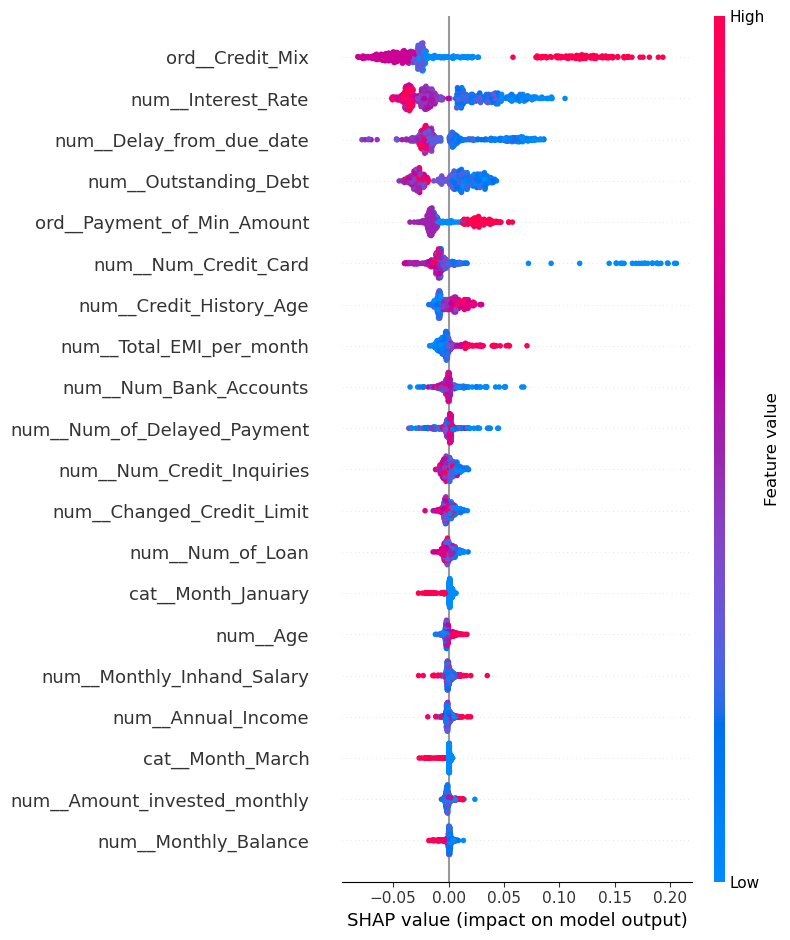

/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_97344/3388526232.py:70: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


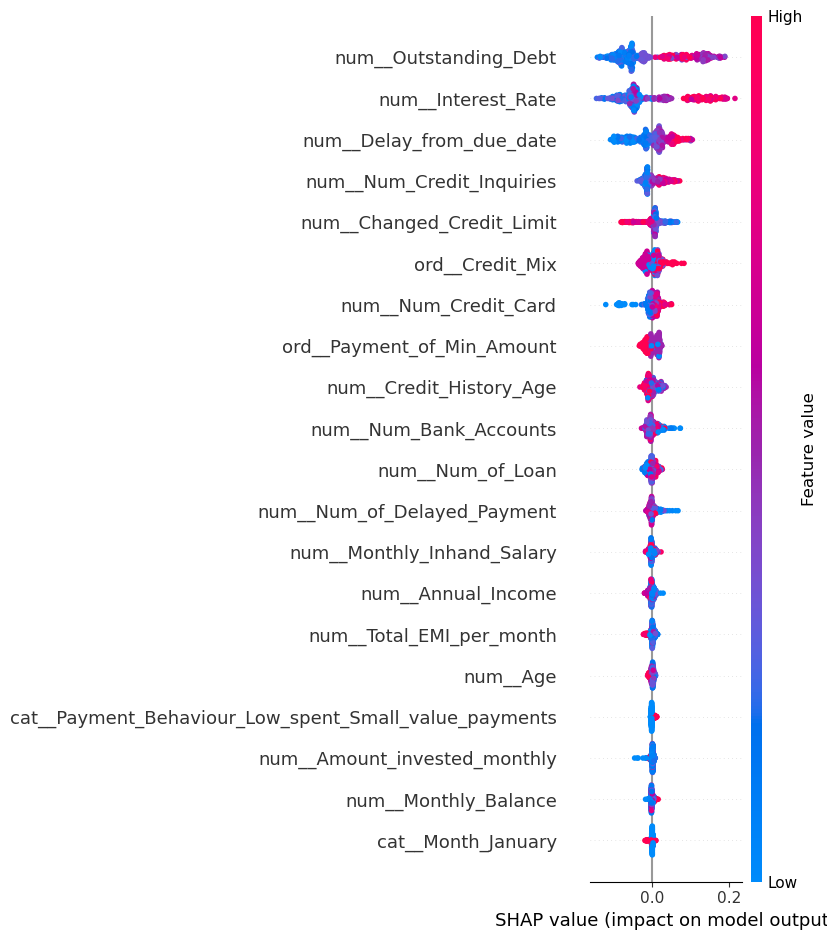

In [14]:
# ===============================
# SHAP for Random Forest (Multiclass, Pipeline-safe)
# ===============================

import shap
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. 从 pipeline 中取模型和预处理
# -------------------------------
rf_model = best_rf.named_steps["model"]
preprocess = best_rf.named_steps["prep"]

# feature names AFTER preprocessing
feature_names = preprocess.get_feature_names_out()

# transform test set
X_test_transformed = preprocess.transform(X_test)

print("Transformed X_test shape:", X_test_transformed.shape)
print("Number of features:", len(feature_names))

# -------------------------------
# 2. 子采样（非常重要，不然会慢）
# -------------------------------
np.random.seed(42)
sample_size = 500
idx = np.random.choice(X_test_transformed.shape[0], sample_size, replace=False)
X_shap = X_test_transformed[idx]

print("SHAP sample shape:", X_shap.shape)

# -------------------------------
# 3. 正确的 SHAP Explainer（关键）
# -------------------------------
explainer = shap.Explainer(
    rf_model,
    X_shap,
    feature_names=feature_names,
    model_output="probability"   # 一定要 probability
)

shap_values = explainer(X_shap)

print("SHAP values shape:", shap_values.values.shape)
# (n_samples, n_features, n_classes)

# -------------------------------
# 4. 类别名称（按你的 label 顺序）
# -------------------------------
class_names = ["Good", "Poor", "Standard"]

# -------------------------------
# 5. SHAP Summary Plot（Good & Poor）
# -------------------------------

# ---- Good class (index = 0) ----
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values.values[:, :, 0],   # Good class
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True
)

# ---- Poor class (index = 1) ----
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values.values[:, :, 1],   # Poor class
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True
)



/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_97344/2904266991.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


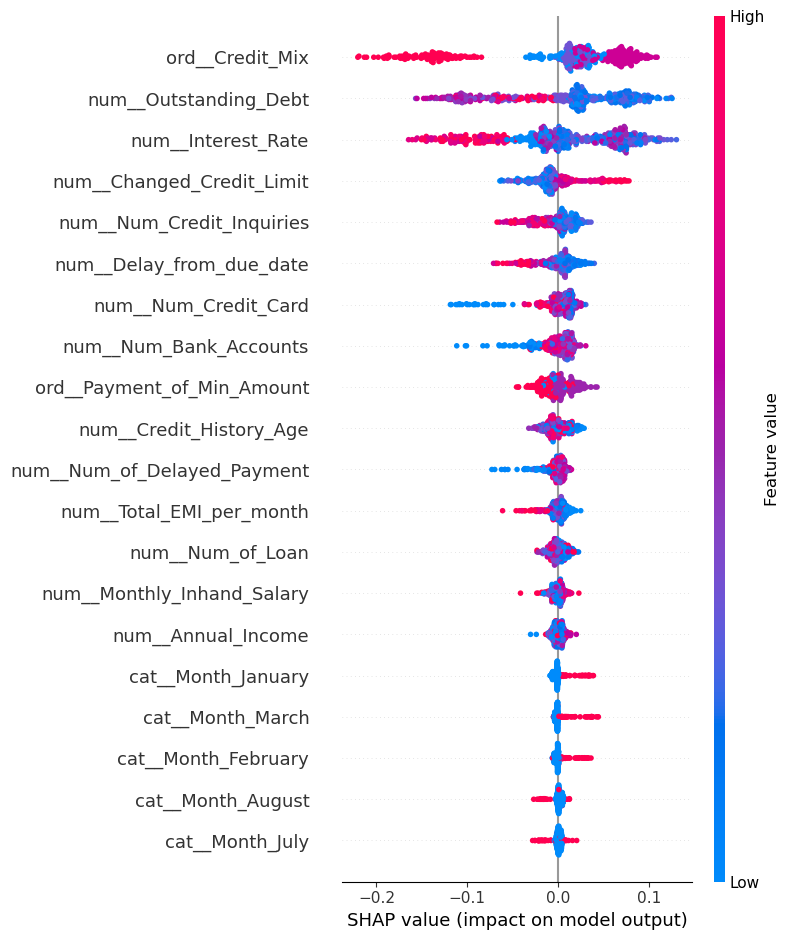

In [15]:
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values.values[:, :, 2],   # Standard class
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True)

In [18]:
best_pipe = rf_grid.best_estimator_
fitted_preprocess = best_pipe.named_steps["prep"]
X_test_transformed = fitted_preprocess.transform(X_test)
feature_names_transformed = fitted_preprocess.get_feature_names_out()
print("n_features (transformed X):", X_test_transformed.shape[1])
print("n_shap_values:", shap_values[0].shape[1])
print("n_feature_names:", len(feature_names_transformed))


n_features (transformed X): 50
n_shap_values: 3
n_feature_names: 50


In [19]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 取 pipeline 里的 RF 模型
rf_model = best_pipe.named_steps["model"]

# 预处理 test set（一定要 transformed）
X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

print("X_test_transformed shape:", X_test_transformed.shape)
print("n_features:", len(feature_names))



X_test_transformed shape: (12638, 50)
n_features: 50


In [22]:
import numpy as np
# RF 预测类别（不是 proba）
y_pred = best_pipe.predict(X_test)

# Find misclassified samples
mis_idx = np.where(y_pred != y_test.values)[0]

if len(mis_idx) == 0:
    raise ValueError("No misclassified samples found.")

target_case = None
for i in mis_idx:
    if y_test.iloc[i] == "Poor" and y_pred_str[i] == "Standard":
        target_case = i
        break

if target_case is None:
    target_case = mis_idx[0]

print("Selected index:", target_case)
print("True label:", y_test.iloc[target_case])
print("Predicted label:", y_pred_str[target_case])



Selected index: 93
True label: Poor
Predicted label: Standard


SHAP shape: (1, 50, 3)


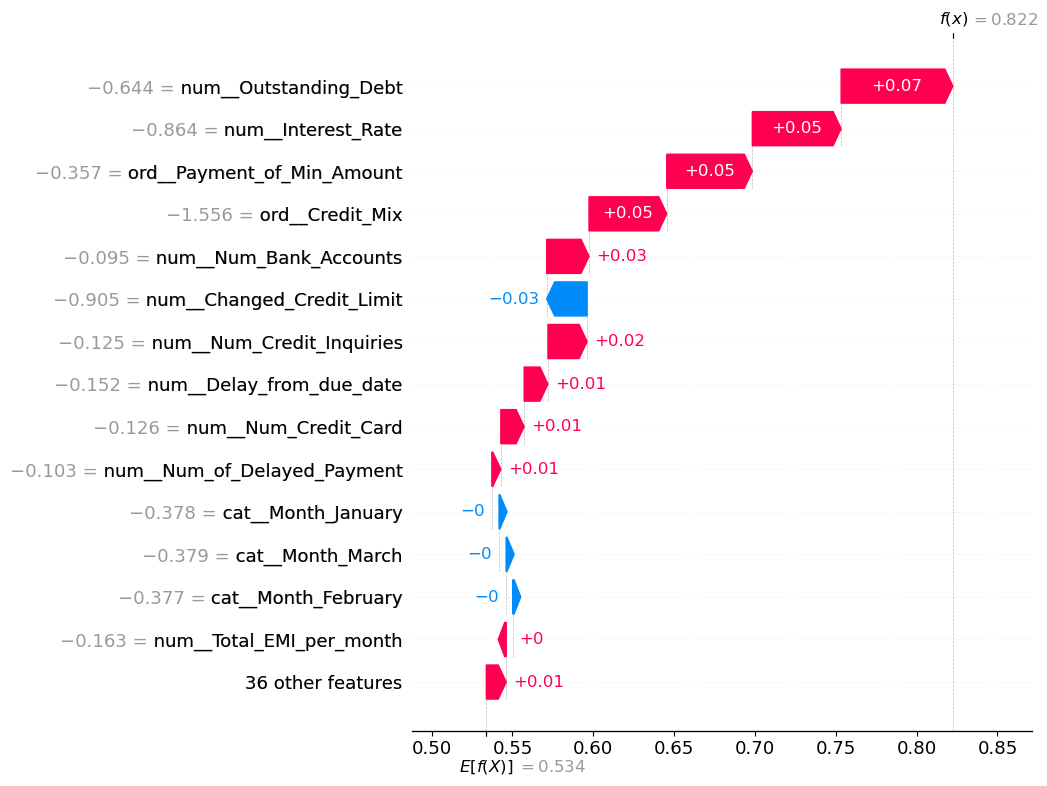

In [27]:
import shap

# 1. 单个样本（transformed）
x_single = X_test_transformed[target_case].reshape(1, -1)

# 2. SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# 3. SHAP values
shap_values_single = explainer.shap_values(x_single)

print("SHAP shape:", shap_values_single.shape)
# (1, n_features, n_classes)

# 4. 选择 predicted class = "Standard"
class_names = ["Good", "Poor", "Standard"]
pred_class = y_pred[target_case]          # already string
pred_class_idx = class_names.index(pred_class)  # 2

# 5. Waterfall plot（✅ 关键修正）
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_single[0, :, pred_class_idx],   # ← 核心
        base_values=explainer.expected_value[pred_class_idx],
        data=x_single[0],
        feature_names=feature_names
    ),
    max_display=15
)


